In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # go up one level so 'blocks' is visible

# DAGs, Simple Regression and Correlation Heatmap

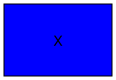

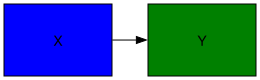

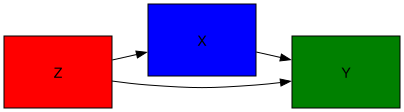

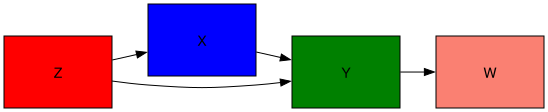

'\n# Optional: Create a png file name with the DAG\ndot.render("filename")\n'

In [2]:
from blocks.draw import draw_duplo_dag_inline
from blocks.sample_dags import start_dag, m_bias_dag
from blocks.add_node import add_node, get_node
from blocks.utils import random_color

# 1️⃣ Start with one block
nodes = start_dag()
draw_duplo_dag_inline(nodes)

# 2️⃣ Add an outcome
add_node(nodes, "Y", "green", targets=[])
get_node(nodes, "X")["targets"].append("Y")  # X → Y
draw_duplo_dag_inline(nodes)

# 3️⃣ Add a confounder
add_node(nodes, "Z", "red", targets=["X", "Y"])  # Z → X, Z → Y
draw_duplo_dag_inline(nodes)

# 4️⃣ Optional: add a random block
add_node(nodes, "W", random_color(), targets=[])
get_node(nodes, "Y")["targets"].append("W")  # Y → W
draw_duplo_dag_inline(nodes)

"""
# Optional: Create a png file name with the DAG
dot.render("filename")
"""

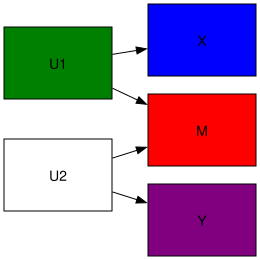

In [3]:
# Manually Create M bias (now saved as a sample DAG)

m_bias = []  # Start empty instead of start_dag()
add_node(m_bias, "U1", "green", targets=["X", "M"])   # Parent first
add_node(m_bias, "U2", "white", targets=["M", "Y"])   # Parent first  
add_node(m_bias, "X", "blue", targets=[])             # Child second
add_node(m_bias, "M", "red", targets=[])              # Child second
add_node(m_bias, "Y", "purple", targets=[])           # Child last

draw_duplo_dag_inline(m_bias)

📊 M-bias DAG structure:


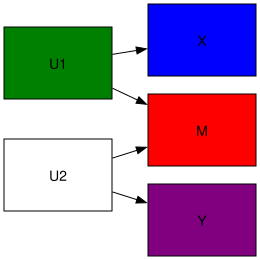

Data preview:
         U1        U2         X         M         Y
0  0.496714  1.399355 -0.178464 -0.011738  0.535862
1 -0.138264  0.924634 -0.282783 -0.074016  0.893430
2  0.647689  0.059630 -0.144731  0.293713  0.077647
3  1.523030 -0.646937  1.215068  2.763781 -0.174306
4 -0.234153  0.698223 -2.127768  1.020623 -0.668635

Data shape: (1000, 5)

📈 Regression 1: Y ~ X (no M control)
Effect of X on Y (no M): -0.0232

📈 Regression 2: Y ~ X + M (controlling for M)
Effect of X on Y (with M): -0.2045
Effect of M on Y: 0.3805


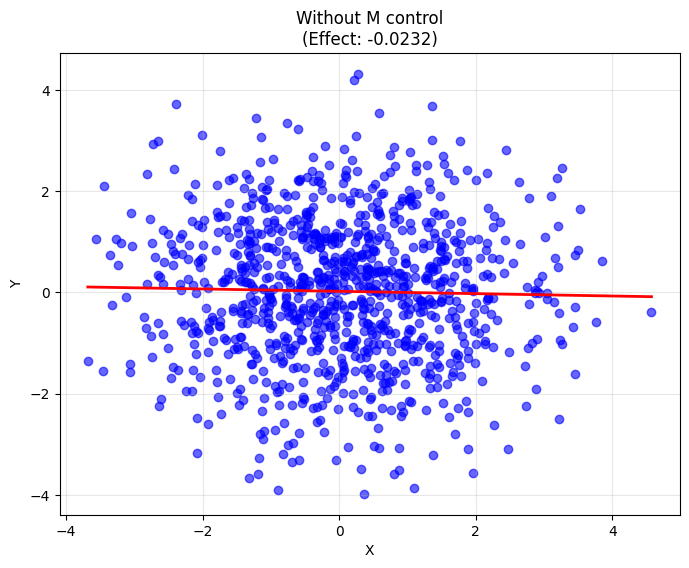

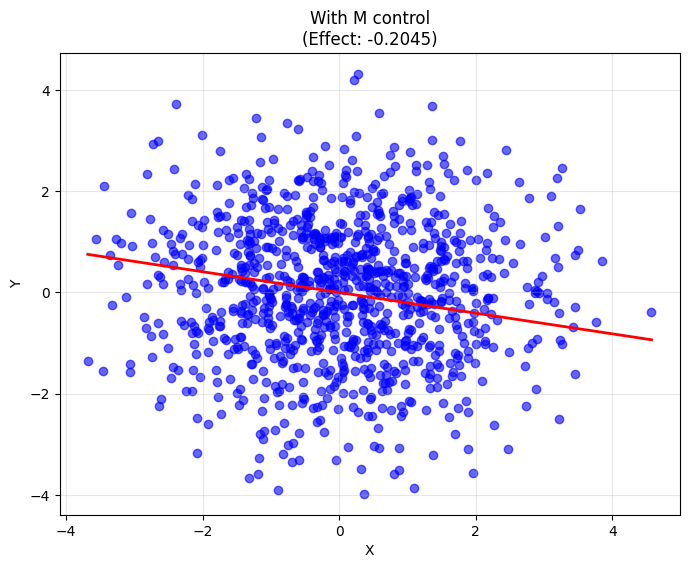

In [8]:
from blocks.simulate import simulate_data
from blocks.regression import regression
from blocks.sample_dags import m_bias_dag
from blocks.plot import plot_regression, correlation_heatmap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Build the M-bias DAG
m_bias = m_bias_dag()

print("📊 M-bias DAG structure:")
draw_duplo_dag_inline(m_bias)

# 2️⃣ Simulate data from this DAG
df = simulate_data(m_bias, n=1000, seed=42)
print("Data preview:")
print(df.head())
print(f"\nData shape: {df.shape}")

# 3️⃣ Regression 1: Y ~ X (without controlling for M)
print("\n📈 Regression 1: Y ~ X (no M control)")
model1 = regression(df, x="X", y="Y", controls=[])
coef1 = model1.params['X']
print(f"Effect of X on Y (no M): {coef1:.4f}")

# 4️⃣ Regression 2: Y ~ X + M (controlling for M)
print("\n📈 Regression 2: Y ~ X + M (controlling for M)")
model2 = regression(df, x="X", y="Y", controls=["M"])
coef2_x = model2.params['X']
coef2_m = model2.params['M']
print(f"Effect of X on Y (with M): {coef2_x:.4f}")
print(f"Effect of M on Y: {coef2_m:.4f}")

# 7️⃣ Visual comparison
plot_regression(df, x="X", y="Y", model=model1, title="Without M control")
plot_regression(df, x="X", y="Y", model=model2, title="With M control")

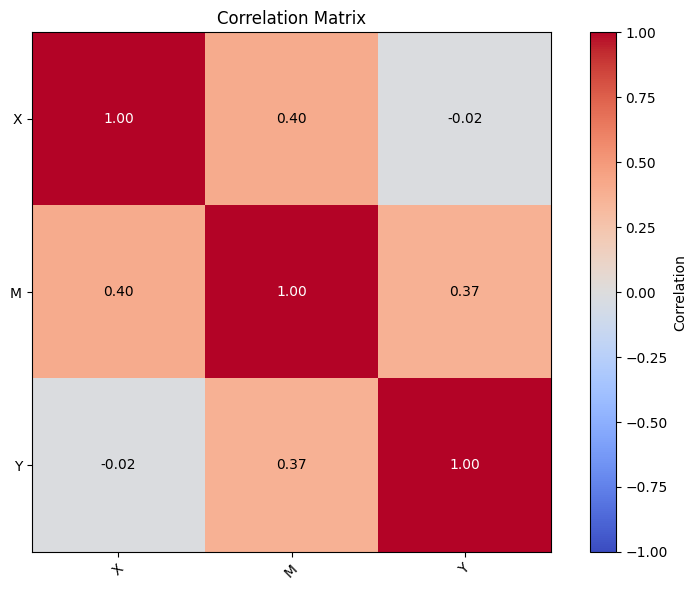

In [5]:
# Quick correlation overview
correlation_heatmap(df, variables=["X", "M", "Y"])